# Introduction
Hey, thanks for viewing my Kernel!

If you like my work, please, leave an upvote: it will be really appreciated and it will motivate me in offering more content to the Kaggle community ! 😊

👉 EDA is done in this [notebook](https://www.kaggle.com/hasanbasriakcay/spaceship-titanic-eda-fe-baseline).

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.simplefilter("ignore")
train = pd.read_csv("../input/spaceship-titanic/train.csv")
test = pd.read_csv("../input/spaceship-titanic/test.csv")
submission = pd.read_csv("../input/spaceship-titanic/sample_submission.csv")

display(train.head())
display(test.head())
display(submission.head())

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


# Feature Engineering

In [2]:
_, _, train["Cabin_3"] = train["Cabin"].str.split("/", expand=True)
_, _, test["Cabin_3"] = test["Cabin"].str.split("/", expand=True)

train.drop(["Name", "Cabin"], axis=1, inplace=True)

# Modelling

In [3]:
%%capture
!pip install pycaret[full]

In [4]:
from pycaret.classification import *

numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
object_cols = list(set(train.columns) - set(numeric_cols))
object_cols.remove("Transported")
ignore_cols = ["PassengerId"]

clf = setup(data=train,
            target='Transported',
            normalize = True,
            normalize_method = 'robust',
            create_clusters = True,
            #feature_interaction = True,
            numeric_features = numeric_cols,
            categorical_features = object_cols,
            ignore_features = ignore_cols,
            session_id = 42,
            use_gpu = False,
            silent = True,
            fold = 10,
            n_jobs = -1)

,Description,Value
0,session_id,42
1,Target,Transported
2,Target Type,Binary
3,Label Encoded,"False: 0, True: 1"
4,Original Data,"(8693, 13)"
5,Missing Values,True
6,Numeric Features,7
7,Categorical Features,4
8,Ordinal Features,False
9,High Cardinality Features,False


In [5]:
N = 2
top = compare_models(sort = 'Accuracy', n_select = N)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.7989,0.8788,0.8228,0.7872,0.8044,0.5976,0.5986,2.9060
lightgbm,Light Gradient Boosting Machine,0.7984,0.8741,0.8192,0.7885,0.8032,0.5966,0.5977,0.1440
gbc,Gradient Boosting Classifier,0.7975,0.8792,0.8343,0.7793,0.8055,0.5949,0.5970,0.2850
ada,Ada Boost Classifier,0.7946,0.8698,0.8222,0.7812,0.8009,0.5890,0.5902,0.1120
lr,Logistic Regression,0.7900,0.8729,0.8035,0.7845,0.7936,0.5799,0.5805,0.5980
xgboost,Extreme Gradient Boosting,0.7888,0.8696,0.8097,0.7792,0.7939,0.5776,0.5785,20.9260
rf,Random Forest Classifier,0.7832,0.8559,0.7679,0.7946,0.7808,0.5665,0.5672,0.4640
et,Extra Trees Classifier,0.7758,0.8413,0.7571,0.7892,0.7726,0.5518,0.5526,0.4280
knn,K Neighbors Classifier,0.7739,0.8437,0.7695,0.7788,0.7739,0.5477,0.5481,0.0940
ridge,Ridge Classifier,0.7657,0.0000,0.7002,0.8090,0.7502,0.5316,0.5370,0.0110


# Stacking

In [6]:
stack = stack_models(top, optimize='Accuracy')
predict_model(stack);

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7865,0.8739,0.8399,0.7604,0.7981,0.5728,0.5760
1,0.7849,0.8749,0.7778,0.7907,0.7842,0.5698,0.5699
2,0.8079,0.8864,0.8529,0.7838,0.8169,0.6156,0.6180
3,0.8046,0.8865,0.8137,0.8006,0.8071,0.6092,0.6092
4,0.7898,0.8644,0.8007,0.7853,0.7929,0.5796,0.5797
5,0.8010,0.8801,0.8203,0.7918,0.8058,0.6019,0.6023
6,0.8010,0.8756,0.8627,0.7697,0.8136,0.6016,0.6062
7,0.7993,0.8766,0.8464,0.7754,0.8094,0.5984,0.6010
8,0.7961,0.8807,0.8203,0.7844,0.8019,0.5920,0.5926
9,0.8257,0.9015,0.8361,0.8199,0.8279,0.6513,0.6514


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.7830,0.8734,0.8294,0.7624,0.7945,0.5654,0.5677


In [7]:
final_stack = finalize_model(stack)

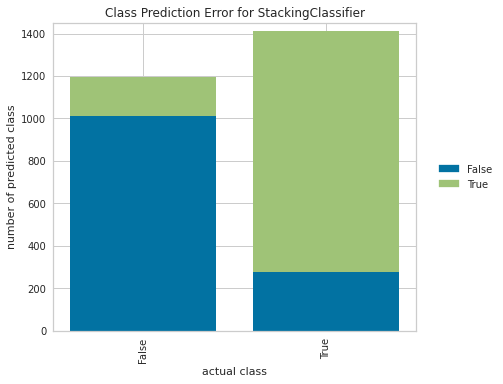

In [8]:
plot_model(final_stack, plot='error')

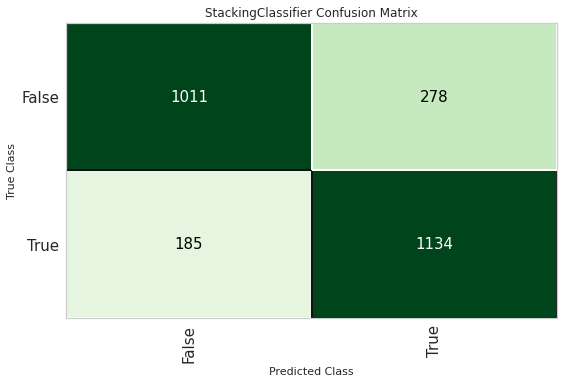

In [9]:
plot_model(final_stack, plot = 'confusion_matrix')

# Blending

In [10]:
blend = blend_models(top, optimize='Accuracy')
predict_model(blend);

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7783,0.8714,0.8301,0.7537,0.7900,0.5564,0.5593
1,0.7882,0.8691,0.7745,0.7980,0.7861,0.5764,0.5767
2,0.8062,0.8813,0.8399,0.7883,0.8133,0.6123,0.6137
3,0.8030,0.8817,0.8072,0.8019,0.8046,0.6059,0.6059
4,0.7898,0.8636,0.7843,0.7947,0.7895,0.5797,0.5797
5,0.7993,0.8727,0.8170,0.7911,0.8039,0.5986,0.5989
6,0.8043,0.8810,0.8627,0.7742,0.8161,0.6082,0.6123
7,0.8026,0.8769,0.8399,0.7835,0.8107,0.6051,0.6067
8,0.7911,0.8830,0.8072,0.7841,0.7955,0.5821,0.5824
9,0.8174,0.8979,0.8328,0.8089,0.8207,0.6348,0.6351


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.7903,0.8749,0.8302,0.7722,0.8001,0.5801,0.5818


In [11]:
final_blend = finalize_model(blend)

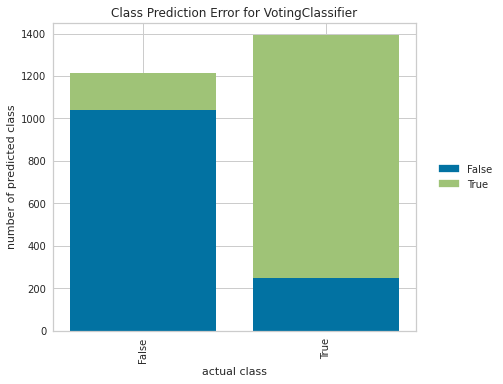

In [12]:
plot_model(final_blend, plot='error')

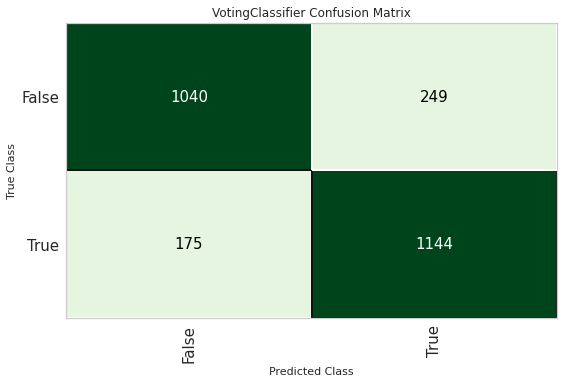

In [13]:
plot_model(final_blend, plot = 'confusion_matrix')

# Ensembling

In [14]:
ensemble = ensemble_model(top[0], method='Bagging')
predict_model(ensemble);

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7734,0.8733,0.8235,0.7500,0.7850,0.5466,0.5492
1,0.7915,0.8682,0.7810,0.7993,0.7901,0.5830,0.5831
2,0.8046,0.8813,0.8366,0.7877,0.8114,0.6091,0.6103
3,0.8013,0.8867,0.8007,0.8033,0.8020,0.6026,0.6026
4,0.7898,0.8650,0.7974,0.7871,0.7922,0.5796,0.5797
5,0.8010,0.8754,0.8105,0.7974,0.8039,0.6019,0.6020
6,0.7977,0.8787,0.8529,0.7699,0.8093,0.5951,0.5986
7,0.7977,0.8791,0.8366,0.7781,0.8063,0.5952,0.5969
8,0.7977,0.8819,0.8203,0.7868,0.8032,0.5953,0.5958
9,0.8191,0.9009,0.8328,0.8115,0.8220,0.6381,0.6383


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.7876,0.8753,0.8271,0.7699,0.7975,0.5747,0.5764


In [15]:
final_ensemble = finalize_model(ensemble)

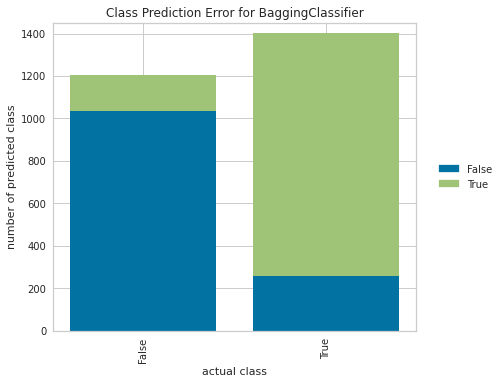

In [16]:
plot_model(final_ensemble, plot='error')

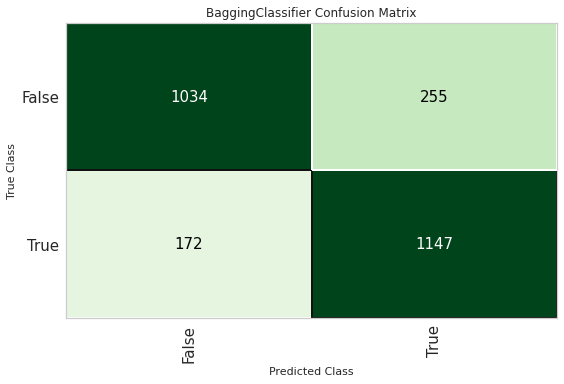

In [17]:
plot_model(final_ensemble, plot = 'confusion_matrix')

# Predictions

In [18]:
import gc
gc.collect()
unseen_predictions_stack = predict_model(final_stack, data=test)
unseen_predictions_blend = predict_model(final_blend, data=test)
unseen_predictions_ensemble = predict_model(final_ensemble, data=test)
unseen_predictions_stack.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Cabin_3,Label,Score
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning,2,True,0.6587
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers,2,False,0.9835
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus,2,True,0.9658
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter,2,True,0.9521
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez,2,True,0.5141


In [19]:
assert(len(test.index)==len(unseen_predictions_stack))
sub = pd.DataFrame(list(zip(submission.PassengerId, unseen_predictions_stack.Label)),columns = ['PassengerId', 'Transported'])
sub.to_csv('submission_stack.csv', index = False)
sub = pd.DataFrame(list(zip(submission.PassengerId, unseen_predictions_blend.Label)),columns = ['PassengerId', 'Transported'])
sub.to_csv('submission_blend.csv', index = False)
sub = pd.DataFrame(list(zip(submission.PassengerId, unseen_predictions_ensemble.Label)),columns = ['PassengerId', 'Transported'])
sub.to_csv('submission_ensemble.csv', index = False)
sub.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [20]:
def plot_preds_dist(df, preds, target, ax=None, title=''):
    train_test_preds = pd.DataFrame()
    train_test_preds['label'] = list(df[target]) + list(preds)
    train_test_preds['train_test'] = 'Test preds'
    train_test_preds.loc[0:len(df[[target]]), 'train_test'] = 'Training'
    
    if ax==None:
        fig, ax = plt.subplots(figsize=(16,3))
        sns.countplot(data=train_test_preds, x='label', hue='train_test', ax=ax)
        ax.set_title(title);
    else:
        sns.countplot(data=train_test_preds, x='label', hue='train_test', ax=ax)
        ax.set_title(title);

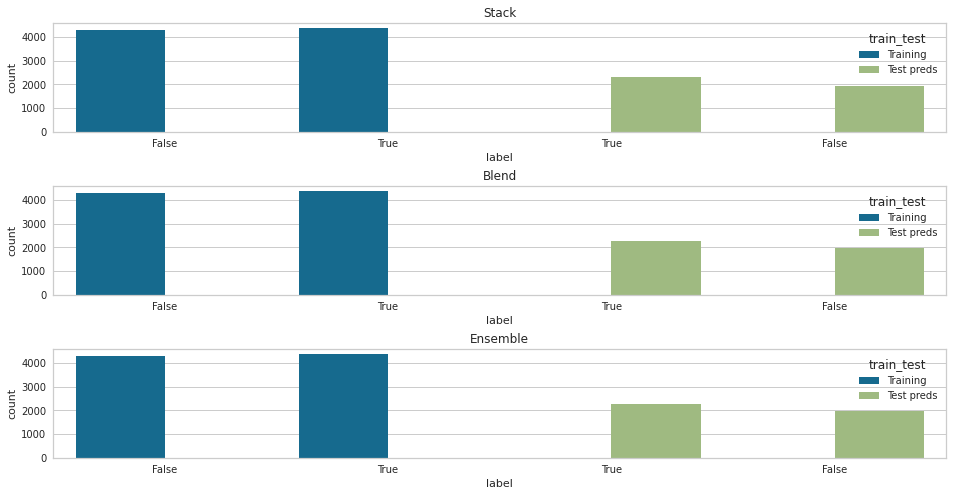

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(16, 8))
plt.subplots_adjust(hspace=0.5)
plot_preds_dist(train, unseen_predictions_stack.Label, "Transported", ax=axes[0], title="Stack")
plot_preds_dist(train, unseen_predictions_blend.Label, "Transported", ax=axes[1], title="Blend")
plot_preds_dist(train, unseen_predictions_ensemble.Label, "Transported", ax=axes[2], title="Ensemble")